In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cleaned_data.csv")


In [4]:
df


,Patient name,Age,Gender,Condition,Medication,Visit date,Blood pressure,Cholesterol,Email,Phone number,Systolic,Diastolic
0,David Lee,25.0,Other,Heart Disease,METFORMIN,2020-01-15,140/90,200.0,name@hospital.org,555-555-5555,140.0,90.0
1,Emily Davis,40.0,Male,Diabetes,No_Medication,2018-04-05,120/80,200.0,Unknown,Unknown,120.0,80.0
2,Laura Martinez,35.0,Other,Asthma,METFORMIN,2019-12-01,110/70,160.0,contact@domain.com,Unknown,110.0,70.0
3,Michael Wilson,40.0,Male,Diabetes,ALBUTEROL,2020-01-15,110/70,180.0,name@hospital.org,555-555-5555,110.0,70.0
4,David Lee,40.0,Female,Asthma,No_Medication,2020-02-20,110/70,180.0,Unknown,,110.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Mary Clark,70.0,Other,Asthma,ALBUTEROL,2019-03-25,110/70,180.0,name@hospital.org,Unknown,110.0,70.0
996,Mary Clark,40.0,Other,NaN,LISINOPRIL,2020-01-15,130/85,160.0,Unknown,123-456-7890,130.0,85.0
997,Laura Martinez,40.0,Other,NaN,ALBUTEROL,2020-02-20,110/70,180.0,name@hospital.org,Unknown,110.0,70.0
998,Jane Smith,25.0,Male,NaN,ALBUTEROL,2018-04-05,110/70,200.0,Unknown,,110.0,70.0


In [5]:
features = df[['Age', 'Cholesterol', 'Systolic', 'Diastolic']]


In [6]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [7]:
inertia = []
K_range = range(1, 10)

In [8]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

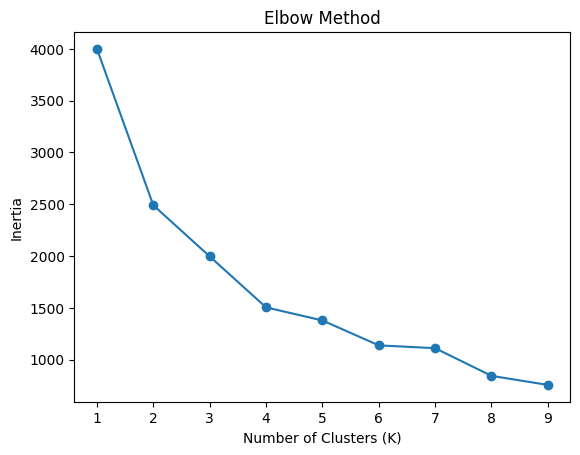

In [9]:
# Plot Elbow Graph
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [11]:
print(df[['Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Cluster']].head())

    Age  Cholesterol  Systolic  Diastolic  Cluster
0  25.0        200.0     140.0       90.0        2
1  40.0        200.0     120.0       80.0        0
2  35.0        160.0     110.0       70.0        0
3  40.0        180.0     110.0       70.0        0
4  40.0        180.0     110.0       70.0        0


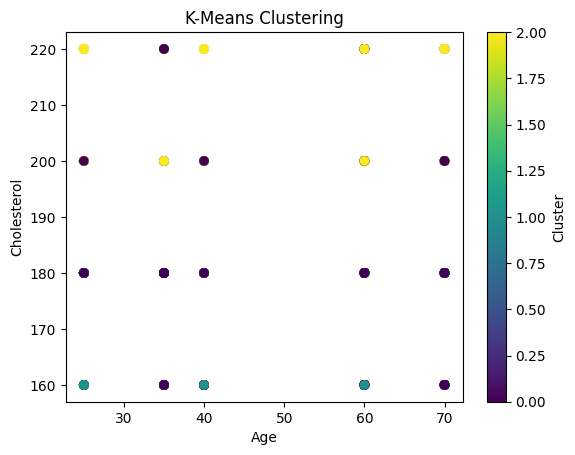

In [13]:
plt.scatter(df['Age'], df['Cholesterol'], c=df['Cluster'], cmap='viridis')
plt.colorbar(label='Cluster')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('K-Means Clustering')
plt.show()

In [14]:
# Get the average values per cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Cholesterol', 'Systolic', 'Diastolic']].mean()
print(cluster_summary)

               Age  Cholesterol    Systolic  Diastolic
Cluster                                               
0        45.604839   182.795699  114.327957  74.327957
1        44.759887   173.615819  133.672316  86.836158
2        43.941606   210.364964  132.445255  86.222628


In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.300


In [16]:
cluster_names = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
df['Cluster_Label'] = df['Cluster'].map(cluster_names)
print(df['Cluster_Label'].value_counts())

Cluster_Label
Low Risk         372
Moderate Risk    354
High Risk        274
Name: count, dtype: int64
